<div style="background-color:#7BAFD4;border-radius:18px;padding:22px 26px;margin-bottom:18px;">
<div style="font-family:Impact,'Arial Black',Arial,sans-serif;font-size:42px;font-weight:900;letter-spacing:2px;line-height:1;color:white;">GEOG 592</div>
<div style="font-family:Arial,Helvetica,sans-serif;font-size:22px;font-weight:700;color:#13294B;margin-top:8px;">GIS Programming</div>
<div style="font-family:Arial,Helvetica,sans-serif;font-size:16px;color:#13294B;margin-top:6px;">GeoPandas — GeoDataFrames and Geometry</div></div>

# From pandas DataFrames to spatial DataFrames

GeoPandas extends pandas by adding geometry and coordinate reference system information.

By the end of this module, you should be able to read spatial data, identify a GeoDataFrame, inspect geometry and CRS, recognize geometry types, use familiar pandas operations, and make a quick map.


## Why GeoPandas matters

A GIS dataset is more than a table. Each row can also contain a geometry.


In [79]:
# Run this only if geopandas is not installed.
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [80]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

## Read a spatial file

In [81]:
stops = gpd.read_file("../Geopandas1/data/chapel_hill_bus_stops.geojson")
# originally from https://gis-portal.townofchapelhill.org/server/rest/services/OpenData/Bus_Stops/FeatureServer/0/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson
# https://gis-portal.townofchapelhill.org/server/rest/services/
# Useful API Code: 0/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson

stops


,OBJECTID,STOP_ID,STOP_ID2,NAME,DIR,ON_,AT,LAT,LONG,A,...,CAN_INSTAL,TRASH_PROB,TRASH_RECO,NEWSPAPER,NEWSPAPER_,BICYCLE,BIKE_SPACE,BIKE_PROBL,BIKE_RECOM,geometry
0,1,3000,3000,Fountain Ridge Rd at Overland Dr,W,Fountain Ridg,Overland Dr,35.936758,-79.008190,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00819 35.93676)
1,2,3001,3001,Summerfield Crossing at Grist Mill,W,Summerfield C,Grist Mill,35.943652,-79.025334,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.02533 35.94365)
2,3,3002,3002,Fountain Ridge Rd at Highview Dr,W,Fountain Ridg,Highview Dr,35.936563,-79.004050,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00405 35.93656)
3,4,3012,3012,Ephesus Church Rd at Sharon Rd,E,Ephesus Churc,Sharon Rd,35.931930,-79.005350,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00535 35.93193)
4,5,3013,3013,Raleigh Rd at Best Western,E,Raleigh Rd,Aurora/Best,35.906650,-79.019990,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01999 35.90665)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,418,3484,3484,W Franklin St at Ham's,W,W Franklin St,Ham's,35.911370,-79.060590,0,...,0,0,0,0,0,1,4,0,0,POINT (-79.06043 35.91145)
592,406,3471,3471,W Franklin St at Kenan St,E,W Franklin St,Abandoned B,35.911380,-79.060140,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.06007 35.91138)
593,364,3423,3423,W Franklin St at University Baptist,E,W Franklin St,University,35.912700,-79.056750,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.05655 35.91275)
594,363,3422,3422,W Franklin St at Caribou Coffee,W,W Franklin St,Caribou Cof,35.912970,-79.056460,0,...,0,0,0,0,0,1,3,0,0,POINT (-79.05651 35.91297)


In [82]:
type(stops)

geopandas.geodataframe.GeoDataFrame

## Familiar pandas operations still work

In [83]:
stops.head()

,OBJECTID,STOP_ID,STOP_ID2,NAME,DIR,ON_,AT,LAT,LONG,A,...,CAN_INSTAL,TRASH_PROB,TRASH_RECO,NEWSPAPER,NEWSPAPER_,BICYCLE,BIKE_SPACE,BIKE_PROBL,BIKE_RECOM,geometry
0,1,3000,3000,Fountain Ridge Rd at Overland Dr,W,Fountain Ridg,Overland Dr,35.936758,-79.008190,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00819 35.93676)
1,2,3001,3001,Summerfield Crossing at Grist Mill,W,Summerfield C,Grist Mill,35.943652,-79.025334,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.02533 35.94365)
2,3,3002,3002,Fountain Ridge Rd at Highview Dr,W,Fountain Ridg,Highview Dr,35.936563,-79.004050,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00405 35.93656)
3,4,3012,3012,Ephesus Church Rd at Sharon Rd,E,Ephesus Churc,Sharon Rd,35.931930,-79.005350,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.00535 35.93193)
4,5,3013,3013,Raleigh Rd at Best Western,E,Raleigh Rd,Aurora/Best,35.906650,-79.019990,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01999 35.90665)


In [84]:
stops.shape

(596, 138)

In [85]:
stops.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [86]:
stops.columns

Index(['OBJECTID', 'STOP_ID', 'STOP_ID2', 'NAME', 'DIR', 'ON_', 'AT', 'LAT',
       'LONG', 'A',
       ...
       'CAN_INSTAL', 'TRASH_PROB', 'TRASH_RECO', 'NEWSPAPER', 'NEWSPAPER_',
       'BICYCLE', 'BIKE_SPACE', 'BIKE_PROBL', 'BIKE_RECOM', 'geometry'],
      dtype='str', length=138)

In [87]:
print(stops[["STOP_ID","geometry"]])
print(type(stops[["STOP_ID","geometry"]]))

     STOP_ID                    geometry
0       3000  POINT (-79.00819 35.93676)
1       3001  POINT (-79.02533 35.94365)
2       3002  POINT (-79.00405 35.93656)
3       3012  POINT (-79.00535 35.93193)
4       3013  POINT (-79.01999 35.90665)
..       ...                         ...
591     3484  POINT (-79.06043 35.91145)
592     3471  POINT (-79.06007 35.91138)
593     3423  POINT (-79.05655 35.91275)
594     3422  POINT (-79.05651 35.91297)
595     3428   POINT (-79.05488 35.9136)

[596 rows x 2 columns]
<class 'geopandas.geodataframe.GeoDataFrame'>


## The geometry column

In [88]:
print(stops.geometry.head())
print(type(stops.geometry))

0    POINT (-79.00819 35.93676)
1    POINT (-79.02533 35.94365)
2    POINT (-79.00405 35.93656)
3    POINT (-79.00535 35.93193)
4    POINT (-79.01999 35.90665)
Name: geometry, dtype: geometry
<class 'geopandas.geoseries.GeoSeries'>


In [89]:
first_geometry = stops.geometry.iloc[0]
print(first_geometry)
print(type(first_geometry))

POINT (-79.00819000053941 35.93675799986392)
<class 'shapely.geometry.point.Point'>


Remember what you know about objects and dot notation:

- `stops` is a GeoDataFrame object
- `stops.geometry` is an attribute
- `stops.head()` is a method
- each individual geometry is also an object


## Geometry types

In [90]:
stops.geom_type

0      Point
1      Point
2      Point
3      Point
4      Point
       ...  
591    Point
592    Point
593    Point
594    Point
595    Point
Length: 596, dtype: str

In [91]:
urban_area = gpd.read_file("../Geopandas1/data/urban_area.geojson")
## from https://gis-portal.townofchapelhill.org/server/rest/services/OpenData/UrbanServiceBoundary/FeatureServer/0/query?where=1%3D1&outFields=*&returnGeometry=true&outSR=4326&f=geojson
print(urban_area.geom_type)
print(urban_area.crs)
urban_area

0    Polygon
dtype: str
EPSG:4326


,OBJECTID,URBANSER_,URBANSER_I,DATE,Shape__Area,Shape__Length,geometry
0,2,2,1,804470400000,7.150418e+08,158917.477493,"POLYGON ((-79.07451 35.87469, -79.07175 35.874..."


In [92]:
print(urban_area.crs)
print(urban_area.total_bounds)
print(len(urban_area))
print(urban_area.geometry.is_empty.sum(), urban_area.geometry.isna().sum())

EPSG:4326
[-79.08873646  35.86077887 -78.99550756  35.97981844]
1
0 0


In [93]:
# importing the parks section
parks = gpd.read_file("../Geopandas1/data/parks copy.geojson")

# changing the CRS
parks = parks.set_crs(epsg = 26917, allow_override=True)
parks = parks.to_crs(epsg=4326) 

parks

,FID,AREA_,PERIMETER,PARCELS_,PARCELS_ID,CREATION,SIZE,OWNER,PIN,TMBL,...,NAME,TYPE,CATEGORY_1,Acres,GlobalID,Acquired,Year,Shape__Area,Shape__Length,geometry
0,1,4.390758e+05,3466.65190,625,624,09/21/2005,A10.1,ORANGE COUNTY,9950114431,2.5..9G,...,Lewis' Heartleaf Preserve,Parkland & open space,Open space,10.079793,{F8631965-0D35-433C-8905-CDB60CEBD9DF},1.127261e+12,2005,6.281121e+04,1309.388751,"POLYGON ((-85.48945 0.00033, -85.48945 0.00033..."
1,2,5.229943e+05,3437.57045,2735,2734,02/27/2004,A12.22,ORANGE COUNTY,9868045156,2.34..3,...,Cedar Grove Park (additional land),Parkland & open space,Open space,12.006297,{7BC4B680-934E-4F45-A5A6-848DA677E36B},1.077840e+12,2004,7.472755e+04,1298.205646,"POLYGON ((-85.48945 0.00033, -85.48945 0.00033..."
2,3,2.901162e+05,4303.44333,2856,2855,11/07/2000,A7.61,ORANGE COUNTY,0818132024,1.21..32,...,Little River Regional Park,Parkland & open space,Existing park,6.660151,{208C409A-D322-4A31-817D-809233335151},9.735552e+11,2000,4.145020e+04,1629.727739,"POLYGON ((-85.48945 0.00033, -85.48945 0.00033..."
3,4,5.430328e+06,11547.06681,3535,3534,11/07/2000,A128.14,ORANGE COUNTY,0807984796,1.21..32A,...,Little River Regional Park,Parkland & open space,Existing park,124.663187,{9C0693DF-31AE-4701-B3ED-568C6CF2D41B},9.735552e+11,2000,7.756036e+05,4362.803990,"POLYGON ((-85.48945 0.00033, -85.48945 0.00033..."
4,5,7.067510e+06,35133.58931,3597,3596,08/04/1967,A156.57,ORANGE COUNTY,9857642370,2.45..5,...,Lake Orange,Parkland & open space,Water & othr utiliti,162.247694,{DF5E7EA1-D1EE-4035-9D8F-D65968CFA79D},-7.603200e+10,1967,1.009220e+06,13281.510025,"POLYGON ((-85.48945 0.00033, -85.48945 0.00033..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,64,6.449701e+05,5641.07811,22490,22489,05/18/1989,S638077,ORANGE COUNTY,9891991328,7.6..92,...,Piney Mountain subdivision (Ph1 & 2),Parkland & open space,Rec & open space,14.806476,{F3162DA0-5847-465E-BB4B-A361E9A827DF},6.113664e+11,1989,8.386166e+04,2123.808981,"POLYGON ((-85.48945 0.00032, -85.48945 0.00032..."
64,65,2.772936e+06,10256.43099,0,0,,,SCHOOL BOARD,,,...,,OPEN SPACE,,0.000000,{D7B8F32F-FDEC-45F1-8029-CEDDCBE399AE},NaN,,3.940999e+05,3866.409721,"POLYGON ((-85.48945 0.00032, -85.48945 0.00032..."
65,66,1.132557e+05,1735.65932,0,0,05/28/2014,2.58,ORANGE COUNTY,9891919120,,...,New Hope Preserve,Parkland & open space,Future park,3.000000,{7583D09E-D5AC-487F-BFC4-771A0BED2A34},1.401235e+12,2014,1.610253e+04,654.140212,"POLYGON ((-85.48945 0.00032, -85.48945 0.00032..."
66,67,4.939797e+05,8802.23809,0,0,10/22/2019,11.34,ORANGE COUNTY,9820428146,,...,Mountains to Sea Trail access,Parkland & open space,Recreation,11.340000,{BE2D21C4-EE51-4931-A8BF-95B3D1E47A1B},1.571702e+12,2019,7.018862e+04,3317.850579,"POLYGON ((-85.48945 0.00032, -85.48945 0.00032..."


## Quick plotting

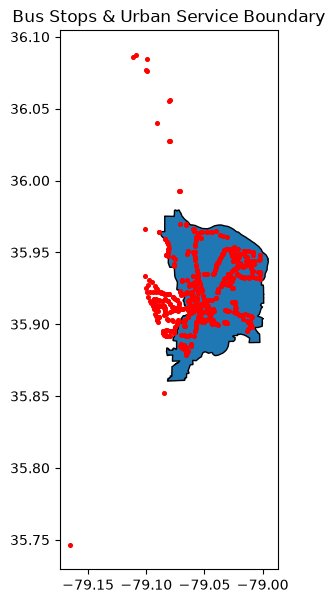

In [94]:
fig, ax = plt.subplots(figsize=(7,7))
urban_area.plot(ax=ax, edgecolor="black")
stops.plot(ax=ax, markersize=7, c="red") 
ax.set_title("Bus Stops & Urban Service Boundary")
plt.show()


The order that you call the layer will have an effect on how it is displayed. 
Notice the difference below when we call the points before the polygon.

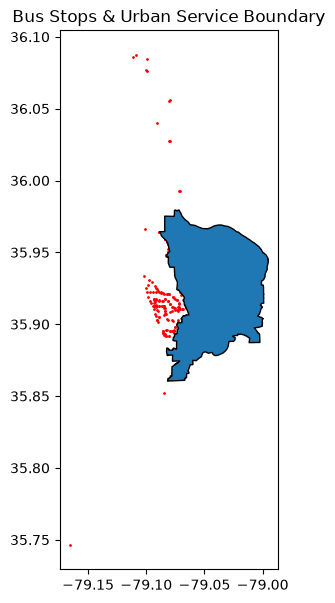

In [95]:
fig, ax = plt.subplots(figsize=(7,7))
stops.plot(ax=ax, markersize=1, c="red")
urban_area.plot(ax=ax, edgecolor="black")
ax.set_title("Bus Stops & Urban Service Boundary")
plt.show()

# when you call the polygon first, they will layer on top of the bus stops and they will not be able to be seen

## Attribute filtering still works

In [96]:
list(stops.columns) ## to see all the columns 

['OBJECTID',
 'STOP_ID',
 'STOP_ID2',
 'NAME',
 'DIR',
 'ON_',
 'AT',
 'LAT',
 'LONG',
 'A',
 'CCX',
 'CL',
 'CM',
 'CPX',
 'CW',
 'D',
 'DX',
 'F',
 'FCX',
 'G',
 'HS',
 'HU',
 'HX',
 'J',
 'JFX',
 'N',
 'NS',
 'NU',
 'PX',
 'RU',
 'S',
 'T',
 'U',
 'V',
 'CMW_SAT',
 'SAT_CM',
 'SAT_CW',
 'DM_SAT',
 'FG_SAT',
 'JN_SAT',
 'NU_WKND',
 'T_SAT',
 'SFR_G',
 'SFR_J',
 'SFR_T',
 'BOARDINGS',
 'ALIGHTING',
 'UPGRADE',
 'SIGN',
 'SHARED',
 'LARGE_SIGN',
 'SMALL_SIGN',
 'SINGLE_POL',
 'SHARED_POL',
 'TELEPHONE_',
 'SIGN_ON_SH',
 'SIGN_ON_BU',
 'SIGN_HEIGH',
 'SIGN_CONDI',
 'SIGN_PROBL',
 'N8_5X11_SC',
 'N6_5X24_SC',
 'LARGE_SQUA',
 'SCHEDULE_M',
 'SCHEDULE_H',
 'NEAR_ADDRE',
 'PROPERTY_U',
 'LANDING_PA',
 'PAD_LOCATI',
 'PAD_MATERI',
 'PAD_PROBLE',
 'ADA_ACCESI',
 'MINABLE_AC',
 'NOT_ACCESS',
 'WHEELCHAIR',
 'SIDEWALK_W',
 'SIDEWALK_C',
 'SIDEWALK_2',
 'SIDEWALK_P',
 'MIDBLOCK_C',
 'INTERSECTI',
 'DISTANCE_F',
 'CURB_CUTS_',
 'CURB_CUTS2',
 'CROSSWALK',
 'CROSSING_S',
 'AUDIBLE_CR',
 'TACTILE_W

In [97]:
stops["CL"].value_counts() # look at the column containing info about the "CL" route

CL
0    520
1     76
Name: count, dtype: int64

In [98]:
#1 means that it has a stop and #0 means it does not
stops1 = stops[stops["CL"] == 1].copy() ## selecting places where CL stops 
stops1

,OBJECTID,STOP_ID,STOP_ID2,NAME,DIR,ON_,AT,LAT,LONG,A,...,CAN_INSTAL,TRASH_PROB,TRASH_RECO,NEWSPAPER,NEWSPAPER_,BICYCLE,BIKE_SPACE,BIKE_PROBL,BIKE_RECOM,geometry
1,2,3001,3001,Summerfield Crossing at Grist Mill,W,Summerfield C,Grist Mill,35.943652,-79.025334,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.02533 35.94365)
80,82,3101,3101,Legion Rd at Britthaven Shelter,E,Legion Rd,Britthaven,35.939620,-79.016700,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.0167 35.93962)
82,84,3103,3103,Legion Rd at Wooded Area (#1719),W,Legion Rd,Wooded Area,35.940400,-79.015720,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01572 35.9404)
83,85,3104,3104,Legion Rd at Forsyth Dr,E,Legion Rd,Forsyth Dr,35.941526,-79.013592,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01359 35.94153)
89,91,3110,3110,Europa Dr at Hotel,W,Europa Dr,Hotel,35.941009,-79.018040,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01804 35.94101)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,404,3469,3469,Summerfield Crossing at Mossbark Ln,E,Summerfield C,Mossbark Ln,35.943781,-79.022083,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.02208 35.94378)
470,480,3555,3555,Old Durham Rd at Cooper St,E,Old Durham Rd,Cooper St,35.944162,-79.008400,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.0084 35.94416)
502,512,3593,3593,Legion Rd at #1718,E,Legion Rd,#1718,35.940490,-79.015420,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01542 35.94049)
577,587,3699,3699,Dobbins Dr. at Erwin,S,Dobbins,Erwin,35.942886,-79.019120,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.01912 35.94289)


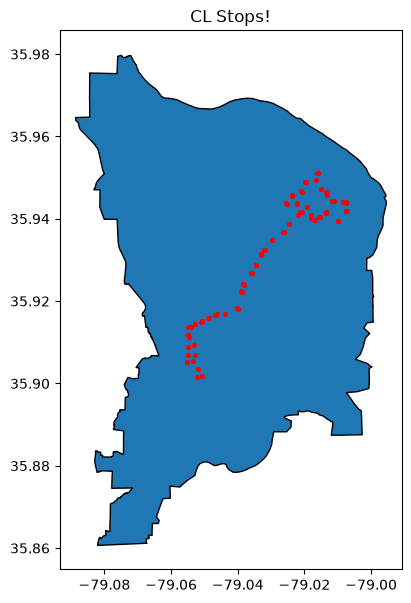

In [99]:
fig, ax = plt.subplots(figsize=(7,7))
urban_area.plot(ax=ax, edgecolor="black")
stops1.plot(ax=ax, markersize=7, c = "red")
ax.set_title("CL Stops!")
plt.show()

## Practice

Using another Chapel Hill geoJSON:

- download two geoJSONs from the Chapel Hill Server (not Stops, not the Boundary)
- inspect the type, shape, and columns
- select the name and geometry columns
- inspect the first geometry
- determine geometry types
- inspect the CRS
- filter the data
- make a copy of the result
- plot the selected features
- publish your work by uploading your JN to your GitHub (week06)


## What to remember

```python
gpd.read_file(...)
gdf.head()
gdf.shape
gdf.geometry
gdf.geom_type
gdf.crs
gdf.plot()
```

The main idea is that GeoPandas keeps the table structure of pandas and adds geometry.
